Imports

In [3]:
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

Create Filtered CSV For EDA

In [14]:
# Notebook-friendly paths (no __file__ in Jupyter)
ROOT = Path.cwd()
DATA_DIR = ROOT / 'data'
TWEETS_PATH = DATA_DIR / 'tweets.txt'
EMOJI_PATH = DATA_DIR / 'emoji.txt'
OUT_CSV = DATA_DIR / 'filtered_tweets.csv'

# Remove all mentions
MENTION_RE = re.compile(r'@\w+')
URL_RE = re.compile(r'https?://\S+|www\.\S+', re.I)
# Remove leading "rt :" retweet prefix
RT_PREFIX_RE = re.compile(r'^\s*rt\s*:\s*', re.I)
SPACE_RE = re.compile(r'\s+')


def clean_tweet(text: str) -> str:
    text = URL_RE.sub('', text)
    text = MENTION_RE.sub('', text)
    text = SPACE_RE.sub(' ', text).strip()
    text = RT_PREFIX_RE.sub('', text)
    return text.strip()


def word_metrics(text: str) -> tuple[int, float]:
    """Whitespace token count and mean token length (chars)."""
    words = text.split()
    n = len(words)
    if not n:
        return 0, 0.0
    return n, sum(len(w) for w in words) / n


rows = []
with open(TWEETS_PATH, encoding='utf-8', errors='replace') as tf, open(
    EMOJI_PATH, encoding='utf-8', errors='replace'
) as ef:
    for line_no, (tweet_line, emoji_line) in enumerate(zip(tf, ef), start=1):
        raw = tweet_line.rstrip('\n\r')
        emoji_label = emoji_line.strip()
        mention_count = raw.count('@')
        is_retweet = raw.lstrip().lower().startswith('rt @')
        tweet_body = clean_tweet(raw)
        char_count = len(tweet_body)
        has_question_mark = '?' in tweet_body
        has_exclamation_mark = '!' in tweet_body
        has_hash = '#' in tweet_body
        capital_letter_count = sum(1 for c in tweet_body if c.isupper())
        word_count, avg_word_length = word_metrics(tweet_body)
        rows.append(
            {
                'LINE_NUM': line_no,
                'TWEET': tweet_body,
                'EMOJI': emoji_label,
                'CHAR_COUNT': char_count,
                'WORD_COUNT': word_count,
                'AVG_WORD_LENGTH': avg_word_length,
                'CAPITAL_LETTER_COUNT': capital_letter_count,
                'MENTION_COUNT': mention_count,
                'HAS_QUESTION_MARK': has_question_mark,
                'HAS_EXCLAMATION_MARK': has_exclamation_mark,
                'HAS_HASH': has_hash,
                'IS_RETWEET': is_retweet,
            }
        )

df = pd.DataFrame(rows)

# Remove dupe tweets
df = df[df['TWEET'].duplicated(keep=False)]
df.to_csv(OUT_CSV, index=False)

print(f'Wrote {len(df)} rows to {OUT_CSV}')

Wrote 100103 rows to c:\Users\avina\Emojithon\data\filtered_tweets.csv


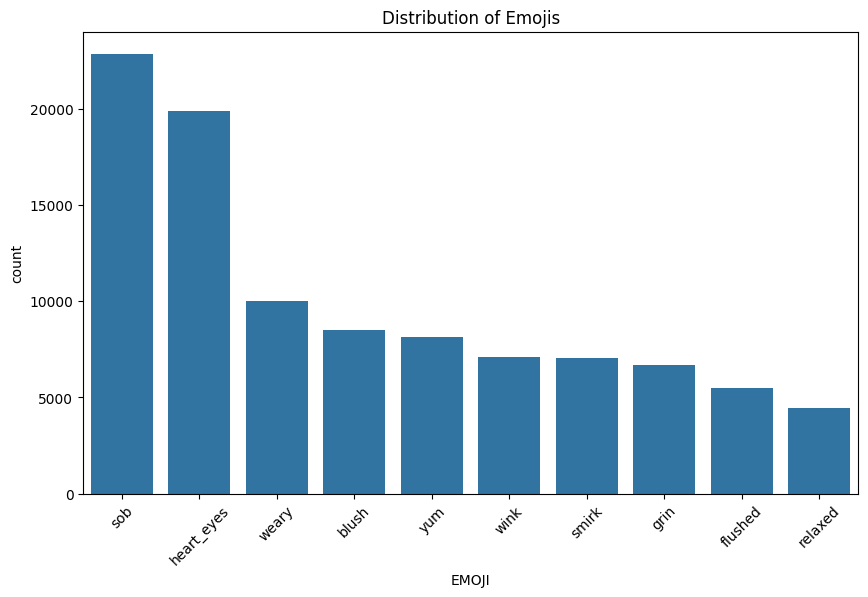

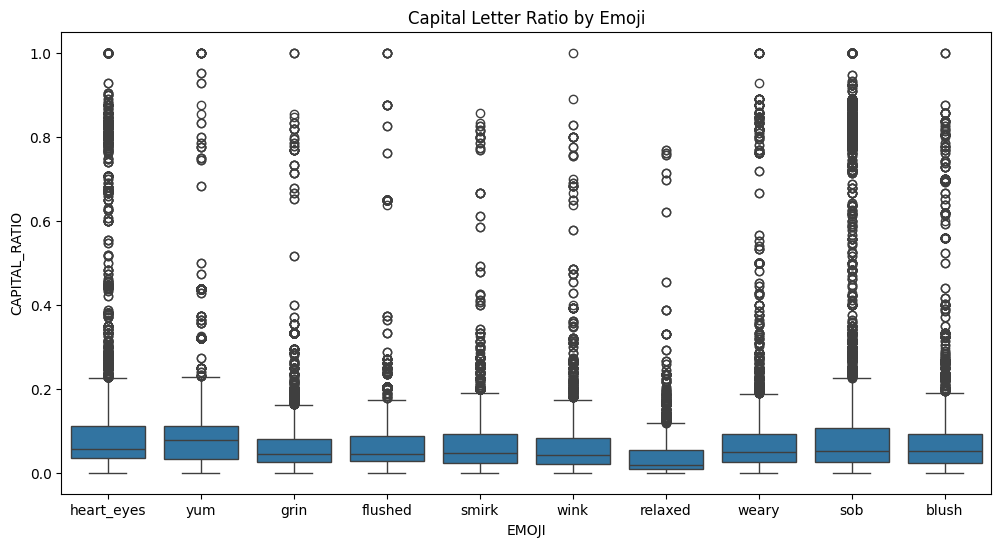

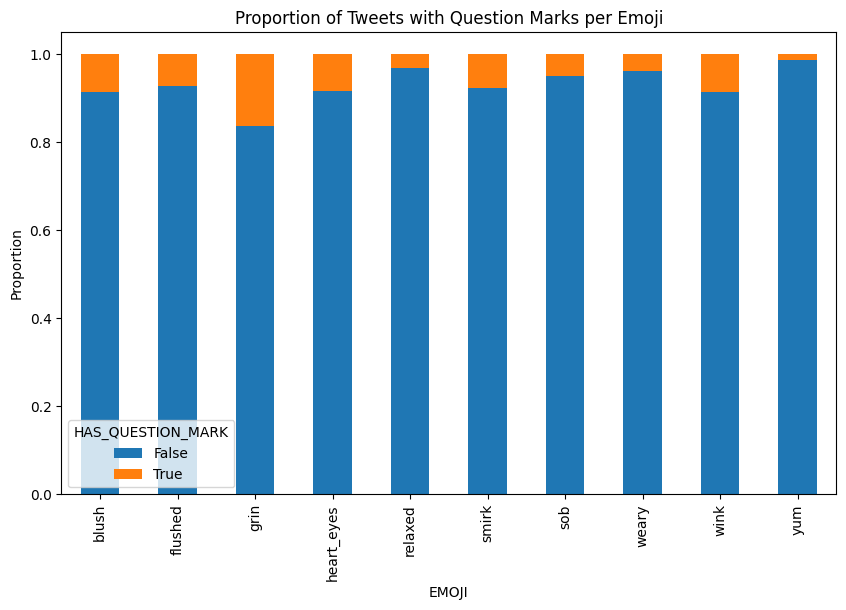

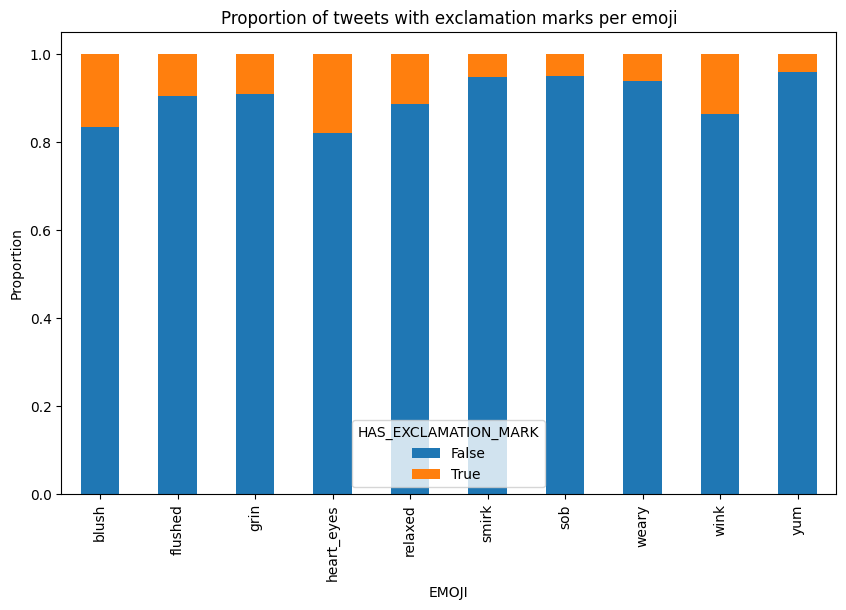

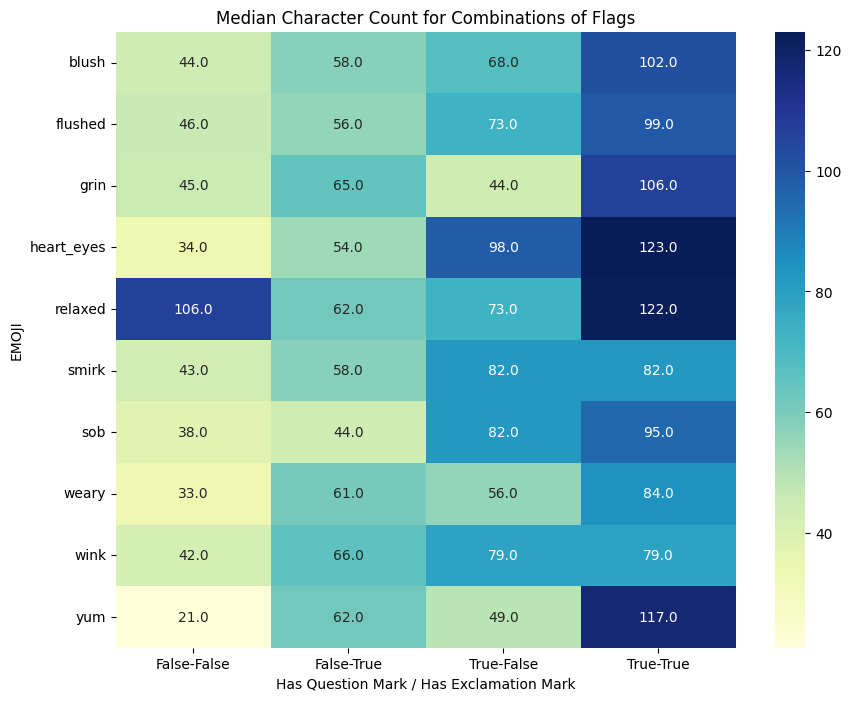

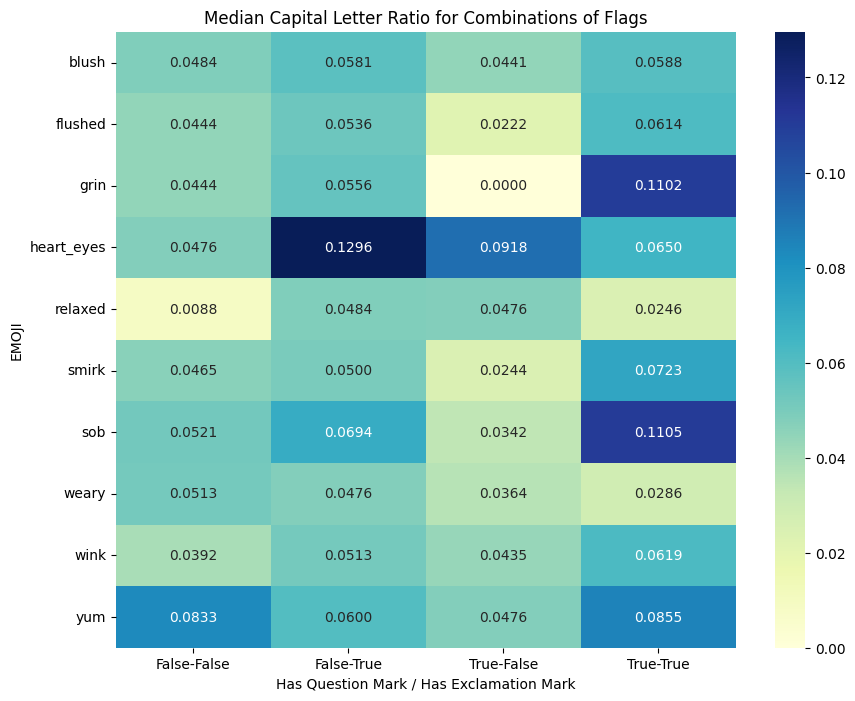

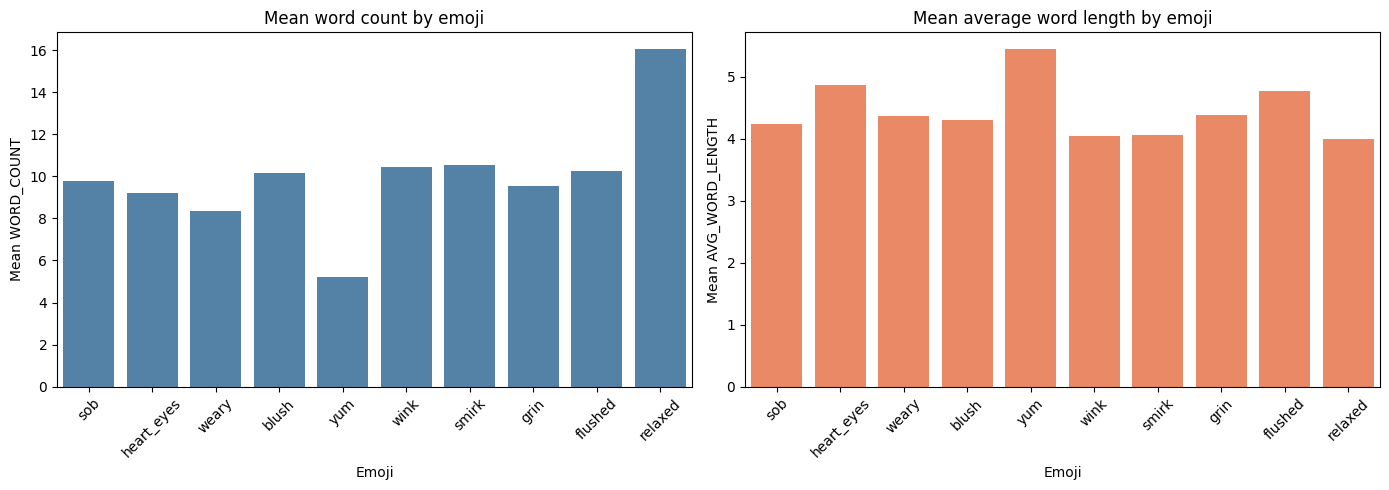

In [16]:
TRAIN_CSV = DATA_DIR / 'filtered_tweets.csv'

df = pd.read_csv(TRAIN_CSV)

# Drop unimportant features
df = df.drop(columns=['LINE_NUM'])

# Calculate capital ratio
df['CAPITAL_RATIO'] = df['CAPITAL_LETTER_COUNT'] / df['CHAR_COUNT']

# 2. Target Distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='EMOJI', order=df['EMOJI'].value_counts().index)
plt.title('Distribution of Emojis')
plt.xticks(rotation=45)
plt.show()

# 3. Capital Letters vs Emoji (Boxplot)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='EMOJI', y='CAPITAL_RATIO')
plt.title('Capital Letter Ratio by Emoji')
plt.show()

# 4. Question Marks vs Emoji (Cross-tabulation)
crosstab = pd.crosstab(df['EMOJI'], df['HAS_QUESTION_MARK'], normalize='index')
crosstab.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Proportion of Tweets with Question Marks per Emoji')
plt.ylabel('Proportion')
plt.show()

# 5. Exclamation marks vs Emoji (cross-tabulation)
crosstab = pd.crosstab(df['EMOJI'], df['HAS_EXCLAMATION_MARK'], normalize='index')
crosstab.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Proportion of tweets with exclamation marks per emoji')
plt.ylabel('Proportion')
plt.show()


# 6. Character Count Distribution
pivot_table = df.pivot_table(
    values='CHAR_COUNT', 
    index='EMOJI', 
    columns=['HAS_QUESTION_MARK', 'HAS_EXCLAMATION_MARK'], 
    aggfunc='median'
)

# Heat map of character count for combinations of flags
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt=".1f")
plt.title('Median Character Count for Combinations of Flags')
plt.xlabel('Has Question Mark / Has Exclamation Mark')
plt.show()

pivot_table = df.pivot_table(
    values='CAPITAL_RATIO', 
    index='EMOJI', 
    columns=['HAS_QUESTION_MARK', 'HAS_EXCLAMATION_MARK'], 
    aggfunc='median'
)

# Heat map of capital letter ratio for combinations of flags
# Not very useful
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt=".4f")
plt.title('Median Capital Letter Ratio for Combinations of Flags')
plt.xlabel('Has Question Mark / Has Exclamation Mark')
plt.show()


# 7. Bar charts: emoji (x) vs mean word count / mean average word length (y)
emoji_order_words = df['EMOJI'].value_counts().index.tolist()
word_by_emoji = (
    df.groupby('EMOJI', observed=False)[['WORD_COUNT', 'AVG_WORD_LENGTH']]
    .mean()
    .reindex(emoji_order_words)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(
    data=word_by_emoji,
    x='EMOJI',
    y='WORD_COUNT',
    order=emoji_order_words,
    ax=axes[0],
    color='steelblue',
)
axes[0].set_title('Mean word count by emoji')
axes[0].set_xlabel('Emoji')
axes[0].set_ylabel('Mean WORD_COUNT')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(
    data=word_by_emoji,
    x='EMOJI',
    y='AVG_WORD_LENGTH',
    order=emoji_order_words,
    ax=axes[1],
    color='coral',
)
axes[1].set_title('Mean average word length by emoji')
axes[1].set_xlabel('Emoji')
axes[1].set_ylabel('Mean AVG_WORD_LENGTH')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [26]:
# Token frequencies across all tweet texts (tokens with 3+ letters only)
# Note: df['TWEET'].value_counts() counts how often the *exact same tweet* appears,
# not individual words.
import re

_token_re = re.compile(r"[a-z0-9']+", re.I)


def tweet_word_tokens(text) -> list[str]:
    return [t for t in _token_re.findall(str(text).lower()) if len(t) >= 3]


_all_tokens: list[str] = []
for tweet in df['TWEET']:
    _all_tokens.extend(tweet_word_tokens(tweet))

word_counts = pd.Series(_all_tokens, name='token').value_counts()
print(
    f'Unique tokens: {word_counts.size:,} | '
    f'Total tokens: {len(_all_tokens):,}'
)
word_counts.to_csv('word_counts.csv', index=True)

Unique tokens: 14,068 | Total tokens: 730,757


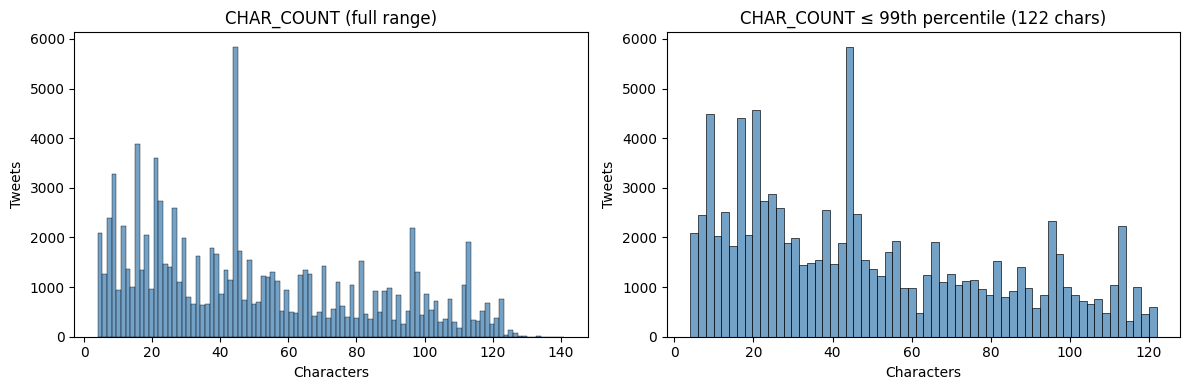

count    100103.000000
mean         49.538126
std          33.228376
min           4.000000
25%          21.000000
50%          44.000000
75%          74.000000
max         141.000000
Name: CHAR_COUNT, dtype: float64


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['CHAR_COUNT'], bins=100, kde=False, ax=axes[0], color='steelblue')
axes[0].set_title('CHAR_COUNT (full range)')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Tweets')

p99 = float(df['CHAR_COUNT'].quantile(0.99))
subset = df.loc[df['CHAR_COUNT'] <= p99, 'CHAR_COUNT']
sns.histplot(subset, bins=60, kde=False, ax=axes[1], color='steelblue')
axes[1].set_title(f'CHAR_COUNT ≤ 99th percentile ({p99:.0f} chars)')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Tweets')

plt.tight_layout()
plt.show()

print(df['CHAR_COUNT'].describe())

In [28]:
df['CHAR_COUNT'].value_counts()

CHAR_COUNT
21     3608
45     3377
9      3280
16     3052
44     2465
       ... 
133       4
132       2
137       2
141       2
135       2
Name: count, Length: 135, dtype: int64

In [30]:
# --- RandomForest (non-XGB); uncomment to use ---
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestClassifier
#
# X = df.drop(columns=['EMOJI', 'TWEET'], errors='ignore').select_dtypes(
#     include=['number', 'bool']
# )
# y = df['EMOJI']
#
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )
#
# model = RandomForestClassifier(n_estimators=100, random_state=42)
# model.fit(X_train, y_train)
#
# pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)


AVG_WORD_LENGTH         0.211194
CHAR_COUNT              0.195372
CAPITAL_RATIO           0.194128
WORD_COUNT              0.121559
CAPITAL_LETTER_COUNT    0.101542
MENTION_COUNT           0.075528
IS_RETWEET              0.032097
HAS_EXCLAMATION_MARK    0.024491
HAS_QUESTION_MARK       0.023907
HAS_HASH                0.020181
dtype: float64

In [34]:
import pandas as pd
import numpy as np
# from sentence_transformers import SentenceTransformer  # non-XGB / BERT pipeline (disabled)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score
from xgboost import XGBClassifier

# 1. Load Data and Prepare Target
df = pd.read_csv(TRAIN_CSV)
le = LabelEncoder()
y = le.fit_transform(df['EMOJI'])

# --- (commented) BERT embedding feature extraction — not XGB; re-enable with SentenceTransformer above ---
# print("Generating BERT Embeddings...")W
# model = SentenceTransformer('all-MiniLM-L6-v2')
# X_bert = np.vstack(model.encode(df['TWEET'].astWype(str).tolist()))

# --- (commented) RandomForest artifact — do not use `model` from SentenceTransformer here ---
# pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

# 2. Numeric / boolean metadata only (same idea as tree models on tabular features)
metadata_cols = (
    df.drop(columns=['EMOJI', 'TWEET'], errors='ignore')
    .select_dtypes(include=['number', 'bool'])
    .columns.tolist()
)
scaler = StandardScaler()
X_meta = scaler.fit_transform(df[metadata_cols])

# --- (commented) Combined BERT + metadata — requires X_bert ---
# X_combined = np.hstack((X_bert, X_meta))

# 3. Split indices (shared if you re-enable BERT / combined)
idx_train, idx_test, y_train, y_test = train_test_split(
    np.arange(len(y)), y, test_size=0.2, random_state=42, stratify=y
)

# 4. XGBClassifier train / eval
def evaluate_model(X_name, X_features):
    print(f"\nTraining Model: {X_name}...")
    X_tr, X_te = X_features[idx_train], X_features[idx_test]
    clf = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
    clf.fit(X_tr, y_train)
    preds = clf.predict(X_te)
    score = f1_score(y_test, preds, average='macro')
    print(f"{X_name} Macro F1-Score: {score:.4f}")
    return score

# 5. Ablation: metadata-only XGB active; BERT / combined commented (non-tabular XGB setups)
score_meta = evaluate_model("Metadata Only (XGB)", X_meta)
# score_bert = evaluate_model("BERT Only (XGB)", X_bert)
# score_combined = evaluate_model("Combined BERT + Meta (XGB)", X_combined)

print("\n--- FINAL RESULTS (XGB only) ---")
print(f"Metadata F1: {score_meta:.4f}")
# print(f"BERT F1:     {score_bert:.4f}")
# print(f"Combined F1: {score_combined:.4f}")


Training Model: Metadata Only (XGB)...


C:\Users\avina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:56:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Metadata Only (XGB) Macro F1-Score: 0.6108

--- FINAL RESULTS (XGB only) ---
Metadata F1: 0.6108


In [ ]:
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier

# Metadata-only XGB predictions (same split as main XGB cell)
_clf_cm = XGBClassifier(
    use_label_encoder=False, eval_metric='mlogloss', random_state=42
).fit(X_meta[idx_train], y_train)
_preds_cm = _clf_cm.predict(X_meta[idx_test])
cm = confusion_matrix(y_test, _preds_cm)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
)
plt.title('XGB (metadata) — Confusion Matrix', fontsize=16)
plt.ylabel('Actual Emoji (True Label)', fontsize=12)
plt.xlabel('Predicted Emoji (Model Guess)', fontsize=12)
plt.show()

NameError: name 'y_test' is not defined

In [ ]:
from xgboost import XGBClassifier

# Metadata-only XGB (BERT / combined ablation commented in main cell)
clf_meta = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss').fit(
    X_meta[idx_train], y_train
)
preds_meta = clf_meta.predict(X_meta[idx_test])

# --- (commented) BERT XGB + meta-vs-BERT disagreement analysis ---
# clf_bert = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss').fit(
#     X_bert[idx_train], y_train
# )
# preds_bert = clf_bert.predict(X_bert[idx_test])
# disagreement_df = pd.DataFrame({
#     'Tweet': df['TWEET'].iloc[idx_test].values,
#     'Actual_Emoji': le.inverse_transform(y_test),
#     'Meta_Guess': le.inverse_transform(preds_meta),
#     'BERT_Guess': le.inverse_transform(preds_bert),
# })
# meta_wins = disagreement_df[
#     (disagreement_df['Actual_Emoji'] == disagreement_df['Meta_Guess'])
#     & (disagreement_df['Actual_Emoji'] != disagreement_df['BERT_Guess'])
# ]
# print(f"Found {len(meta_wins)} tweets where Metadata beat BERT.")
# for idx, row in meta_wins.head(20).iterrows():
#     print(f"\nActual: {row['Actual_Emoji']} | BERT Guessed: {row['BERT_Guess']}")
#     print(f"Tweet: {row['Tweet']}")